In [277]:
import scarf
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
scarf.__version__

'0.32.3'

In [6]:
# read the .h5ad data. If using other formats and need help converting, go to https://scarf.readthedocs.io/en/latest/vignettes/download_conversion.html
##### Only need to run THIS CMD initially to process the data
reader = scarf.H5adReader(
    h5ad_fn="external_segment_globus_pallidus.h5ad",
    cell_ids_key="CellID",          
    feature_ids_key="_index",        
    feature_name_key="feature_name", 
    matrix_key="X",                     
)
# now write it to the .Zarr format that it wants to be in

writer = scarf.H5adToZarr(
    reader,
    zarr_loc='externalGP.zarr',
    chunk_size=(2000,1000)
)
writer.dump()



INFO: No value provided for assay names. Will use default value: 'RNA'


Reading attributes from group obs:   0%|                                                                      …

Reading attributes from group obsm:   0%|                                                                     …

Reading attributes from group var:   0%|                                                                      …

  0%|                                                                                                         …

In [5]:
ds = scarf.DataStore(
    'externalGP.zarr', # same loco as where you saved the zarr
    nthreads=4,
    min_features_per_cell = 10 # only genes in more than 10 cells will be kept    
)
# reason it is safe to use a scalar factor of 1k even though we have cells with less reads is bc we filter them out in next step

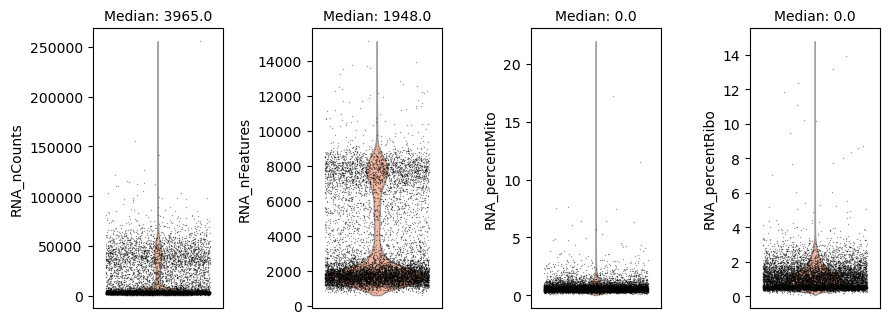

In [11]:
ds.plot_cells_dists(cell_key='I', color='coral')

In [19]:
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures'],
    highs=[50000, 8500],
    lows=[1000, 500]
)
## since the external segment of the globus pallidus appears to be so weird... I think I will likely do an stringent upper threshold and lower threshold. Not sure if its becuase their is UMI
## duplicates or thats the actual single nucleus morphology here

INFO: 3061 cells flagged for filtering out using attribute RNA_nCounts
INFO: 1650 cells flagged for filtering out using attribute RNA_nFeatures


In [6]:
ds.cells.head()

,I,ids,names,RNA_UMAP1,RNA_UMAP2,RNA_cluster,RNA_leiden_cluster,RNA_nCounts,RNA_nFeatures,RNA_percentMito,...,X_UMAP2,X_tSNE1,X_tSNE2,cell_cycle_score,fraction_mitochondrial,fraction_unspliced,is_primary_data,observation_joinid,total_UMIs,total_genes
0,True,10X393_8:CCCTAACCACGGGCTT,10X393_8:CCCTAACCACGGGCTT,-10.812319,3.452168,7,6,2785.0,1113.0,0.574506,...,7.737397,-27.206246,18.299157,0.000710,0.000710,0.805398,True,7}aZT?-f2(,2816.0,1125.0
1,True,10X393_8:GAGGGATCACCACATA,10X393_8:GAGGGATCACCACATA,-7.735462,-14.247728,3,6,1762.0,967.0,0.510783,...,-0.597485,-30.914347,11.713705,0.003384,0.001692,0.644106,True,aum;Lzw`B$,1773.0,974.0
2,True,10X393_8:TTAGGGTCAACTGCCG,10X393_8:TTAGGGTCAACTGCCG,25.359505,-2.053391,4,3,10412.0,3899.0,1.142912,...,-0.304631,-23.654295,23.684211,0.001437,0.007857,0.761905,True,NylYvfO4b4,10437.0,3916.0
3,True,10X393_7:CCACGTTCAACTGGTT,10X393_7:CCACGTTCAACTGGTT,2.468949,11.737015,27,15,8419.0,3601.0,1.662905,...,8.092102,-26.489448,18.037304,0.001185,0.012201,0.616679,True,9TMF_Viq(e,8442.0,3620.0
4,True,10X419_1:TAGAGTCTCTAGGAAA,10X419_1:TAGAGTCTCTAGGAAA,6.695495,10.234308,10,11,20592.0,5984.0,0.568182,...,10.061797,-23.547928,28.802856,0.001401,0.000145,0.742656,True,aaG!wZb154,20696.0,6032.0


In [7]:
ds.RNA.feats.head()

,I,ids,names,I__hvgs,dropOuts,feature_is_filtered,nCells
0,True,ENSG00000271098,IMMP1LP3,True,50783,False,47
1,True,ENSG00000251026,NIHCOLE,True,50412,False,418
2,True,ENSG00000129451,KLK10,False,50690,False,140
3,True,ENSG00000163568,AIM2,False,49841,False,989
4,True,ENSG00000253327,RAD21-AS1,False,50687,False,143


In [8]:
ds ## takes us down to 47.5k cells total

DataStore has 47568 (50830) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_UMAP1', 'RNA_UMAP2', 
            'RNA_cluster', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 
            'RNA_percentRibo', 'X_UMAP1', 'X_UMAP2', 'X_tSNE1', 'X_tSNE2', 
            'cell_cycle_score', 'fraction_mitochondrial', 'fraction_unspliced', 'is_primary_data', 'observation_joinid', 
            'total_UMIs', 'total_genes'
   RNA assay has 31569 (58232) features and following metadata:
            'I', 'ids', 'names', 'I__hvgs', 'dropOuts', 
            'feature_is_filtered', 'nCells'

INFO: Calculating summary statistics
INFO: Using cached feature stats for cell_key I
INFO: Using existing corrected dispersion values
INFO: Calculating HVGs
INFO: 1990 genes marked as HVGs


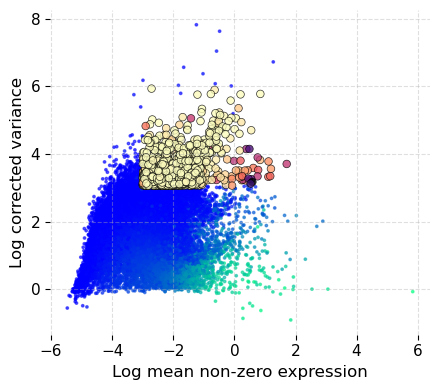

In [9]:
ds.mark_hvgs(
    min_cells=20, # genes found in at least 20 of the cells
    top_n=2000, # means the top 2k highly variable genes
    min_mean=-3,
    max_mean=2,
    max_var=6
)

In [10]:
ds.RNA.feats.head()

,I,ids,names,I__hvgs,dropOuts,feature_is_filtered,nCells,stats_I_avg,stats_I_c_var__200__0.1,stats_I_normed_n,stats_I_normed_tot,stats_I_nz_mean,stats_I_sigmas
0,True,ENSG00000271098,IMMP1LP3,True,50783,False,47,0.000095,9.061598,37.0,4.845531,0.130960,0.000032
1,True,ENSG00000251026,NIHCOLE,True,50412,False,418,0.000770,8.657837,284.0,39.145037,0.137835,0.000349
2,True,ENSG00000129451,KLK10,False,50690,False,140,0.000184,7.751044,68.0,9.332586,0.137244,0.000060
3,True,ENSG00000163568,AIM2,False,49841,False,989,0.001649,6.840544,758.0,83.833196,0.110598,0.000665
4,True,ENSG00000253327,RAD21-AS1,False,50687,False,143,0.000215,6.175565,98.0,10.934750,0.111579,0.000062


In [11]:
ds.make_graph(
    feat_key='hvgs',
    k=11,
    dims=30, ## dims is about the of PCA dimensions
    n_centroids=100
)

INFO: Using existing normalized data with cell key I and feat key I__hvgs
INFO: Using existing loadings for pca with 30 dims
INFO: Using existing ANN index
INFO: using existing kmeans cluster centers
INFO: KNN graph already exists will not recompute.


In [12]:
ds.run_umap(
    n_epochs = 250,
    spread=5,
    min_dist=1,
    parallel=True
)

Training UMAP:   0%|                                                                                          …

	completed  0  /  250 epochs
	completed  25  /  250 epochs
	completed  50  /  250 epochs
	completed  75  /  250 epochs
	completed  100  /  250 epochs
	completed  125  /  250 epochs
	completed  150  /  250 epochs
	completed  175  /  250 epochs
	completed  200  /  250 epochs
	completed  225  /  250 epochs


/opt/anaconda3/lib/python3.12/site-packages/scarf/metadata.py:334: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


In [31]:
ds.cells.head()

,I,ids,names,RNA_UMAP1,RNA_UMAP2,RNA_nCounts,RNA_nFeatures,RNA_percentMito,RNA_percentRibo,X_UMAP1,X_UMAP2,X_tSNE1,X_tSNE2,cell_cycle_score,fraction_mitochondrial,fraction_unspliced,is_primary_data,observation_joinid,total_UMIs,total_genes
0,True,10X393_8:CCCTAACCACGGGCTT,10X393_8:CCCTAACCACGGGCTT,-10.812319,3.452168,2785.0,1113.0,0.574506,0.682226,15.869685,7.737397,-27.206246,18.299157,0.000710,0.000710,0.805398,True,7}aZT?-f2(,2816.0,1125.0
1,True,10X393_8:GAGGGATCACCACATA,10X393_8:GAGGGATCACCACATA,-7.735462,-14.247728,1762.0,967.0,0.510783,1.589103,12.252677,-0.597485,-30.914347,11.713705,0.003384,0.001692,0.644106,True,aum;Lzw`B$,1773.0,974.0
2,True,10X393_8:TTAGGGTCAACTGCCG,10X393_8:TTAGGGTCAACTGCCG,25.359505,-2.053391,10412.0,3899.0,1.142912,0.768344,14.976462,-0.304631,-23.654295,23.684211,0.001437,0.007857,0.761905,True,NylYvfO4b4,10437.0,3916.0
3,True,10X393_7:CCACGTTCAACTGGTT,10X393_7:CCACGTTCAACTGGTT,2.468949,11.737015,8419.0,3601.0,1.662905,1.187790,16.006760,8.092102,-26.489448,18.037304,0.001185,0.012201,0.616679,True,9TMF_Viq(e,8442.0,3620.0
4,True,10X419_1:TAGAGTCTCTAGGAAA,10X419_1:TAGAGTCTCTAGGAAA,6.695495,10.234308,20592.0,5984.0,0.568182,0.796426,16.345463,10.061797,-23.547928,28.802856,0.001401,0.000145,0.742656,True,aaG!wZb154,20696.0,6032.0


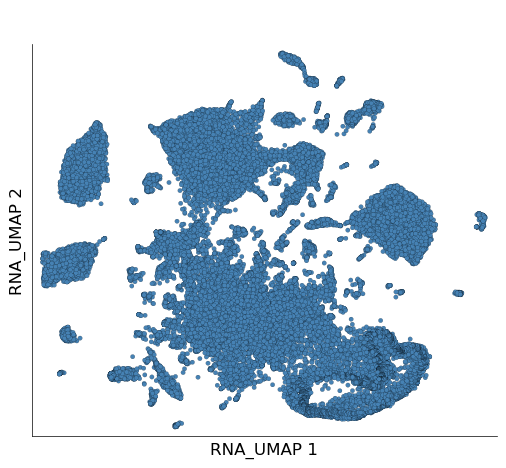

In [32]:
ds.plot_layout(layout_key='RNA_UMAP')

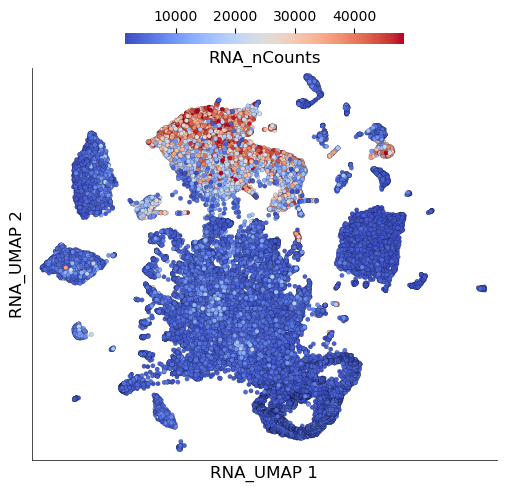

In [13]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_nCounts',
    cmap='coolwarm' # visualize data from each column
)

In [51]:
ds.run_leiden_clustering(resolution=.65) # closer to 0 resolution means less clusters, closer to 1 means more clusters

/opt/anaconda3/lib/python3.12/site-packages/scarf/metadata.py:334: RuntimeWarning: invalid value encountered in cast
  a = np.empty(self.N).astype(values.dtype)


/opt/anaconda3/lib/python3.12/site-packages/scarf/plots.py:597: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


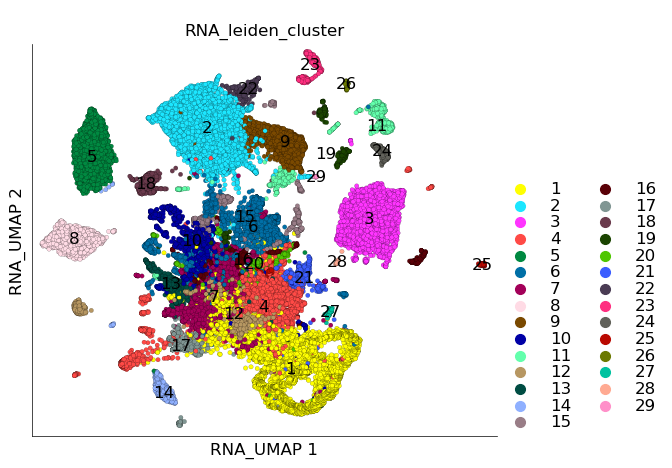

In [14]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)
#savename=None, save_dpi=300

In [15]:
leiden_clusters = ds.cells.to_pandas_dataframe( # output the leiden cluster info into a pds df
    columns=['RNA_leiden_cluster'],
    key='I'
)

In [16]:
leiden_clusters

,RNA_leiden_cluster
0,6
1,6
2,3
3,15
4,11
...,...
50825,16
50826,16
50827,16
50828,9


In [17]:
ds.run_clustering(n_clusters=leiden_clusters.nunique().iloc[0]) ## make it so that the total # of RNA clusters match the # of leiden clusters

INFO: Using existing dendrogram


In [ ]:
ds.run_marker_search(
    group_key='RNA_cluster',
    gene_batch_size=100
)

Finding markers:   0%|                                                                                        …

In [ ]:
ds.plot_marker_heatmap(
    group_key='RNA_cluster',
    topn=5,
    figsize=(6,10)
)

In [19]:
markers = ds.get_markers(
    group_key='RNA_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1
)
markers

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value
0,1,LINC03096,34156.0,0.48579,0.01844,0.00023,0.28066,0.00332,79.24045,0.000000e+00
1,1,ENSG00000255029,34163.0,0.44194,0.02923,0.00048,0.31001,0.00547,60.77191,0.000000e+00
2,1,ENSG00000286260,34122.0,0.42437,0.05488,0.00101,0.62805,0.01334,54.08374,0.000000e+00
3,1,ENSG00000285634,322.0,0.42189,0.03705,0.00077,0.44616,0.00736,48.09702,0.000000e+00
4,1,ENSG00000259620,291.0,0.42139,0.01103,0.00038,0.22330,0.00290,29.34219,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
31564,1,ZFP36L1,56648.0,0.00026,0.00141,0.21619,0.01250,0.20768,0.00652,0.000000e+00
31565,1,TGFBR2,1265.0,0.00024,0.00066,0.11159,0.00547,0.12539,0.00594,3.960257e-250
31566,1,FLI1,1583.0,0.00024,0.00044,0.07580,0.01183,0.09765,0.00575,1.887981e-161
31567,1,CX3CR1,1655.0,0.00022,0.00022,0.17433,0.00402,0.12360,0.00128,4.994279e-252


In [20]:
from scipy.stats import beta as beta_dist
import numpy as np

In [187]:
## new trinarizer
def trinarize_gene_in_cluster(counts, f=0.2, confidence_threshold=0.95, confidence_low=0.05):
    n = len(counts) #tells us the total cells in the cluster
    k = np.sum(counts > 0) #making sure only cells with at least 1 count
   
    #defining the same prior as they did previously
    alpha_prior = 1.5
    beta_prior = 2.0
    
    #does the bayesian update and evalutes the posterior
    alpha_post = k + alpha_prior
    beta_post = (n - k) + beta_prior
    
    #this calculates the probability that the true fraction of cells expressing gene x :is > f (20%)
    #the beta.cdf part integrates the function f and gives us the AUC 
    #then 1 - cdf gives the area above the function f
    p_confidence = 1.0 - beta_dist.cdf(f, alpha_post, beta_post)
    
    # now just put the 95% cutoff, so that means 95% confident, or FDR of 0.05, if doesn't fit into either, denote as ambigiouys
    if p_confidence >= confidence_threshold:
        call = 'on'
    elif p_confidence <= confidence_low:
        call = 'off'
    else:
        call = 'ambiguous' 
        
    scores = {'p_confidence': p_confidence}
    return call, scores

def build_trinarization_matrix(ds, cluster_key='RNA_leiden_cluster'):
    x = ds.cells.fetch_all(cluster_key)
    genes = ds.RNA.feats.fetch_all('names') 
    clusters = np.unique(x) 
    # create the results dictionary here
    results = {}
    for cluster in clusters:
        mask = x == cluster 
        cluster_counts = ds.RNA.rawData[mask].compute() 
        results[cluster] = {}
        for i, gene in enumerate(genes):
            gene_counts = cluster_counts[:,i].flatten() 
            call, _ = trinarize_gene_in_cluster(gene_counts)
            results[cluster][gene] = call
            
    return results

In [188]:
results = build_trinarization_matrix(ds) # takes a while

In [191]:
results # do results[some number] for a specific page in the dcit

{-1: {'IMMP1LP3': 'off',
  'NIHCOLE': 'off',
  'KLK10': 'off',
  'AIM2': 'off',
  'RAD21-AS1': 'off',
  'FER1L6': 'off',
  'ENSG00000220256': 'off',
  'ENSG00000287502': 'off',
  'MYOZ1': 'off',
  'ENSG00000273295': 'off',
  'ENSG00000231069': 'off',
  'ENSG00000287548': 'off',
  'ENSG00000250267': 'off',
  'NRTN': 'off',
  'XIRP2': 'off',
  'HLX-AS1': 'off',
  'BSPH1': 'off',
  'KRT39': 'off',
  'LINC00896': 'off',
  'LINC00492': 'off',
  'MROCKI': 'off',
  'EPSTI1': 'off',
  'EXPH5': 'on',
  'ENG': 'off',
  'LINC02267': 'off',
  'GGTA1': 'off',
  'FAM111A-DT': 'off',
  'H2AC17': 'off',
  'SAMSN1': 'off',
  'CYBA': 'off',
  'GJD2': 'off',
  'PTH1R': 'off',
  'BHLHE22': 'off',
  'LDHBP3': 'off',
  'KRT17': 'off',
  'ENSG00000262495': 'off',
  'ENSG00000272864': 'off',
  'PVALB': 'off',
  'AQP3': 'off',
  'CLCNKB': 'off',
  'EN2': 'off',
  'ENSG00000272717': 'off',
  'LINC02058': 'off',
  'C1R': 'off',
  'SERTM1': 'off',
  'C1QL2': 'off',
  'ENSG00000286285': 'off',
  'NRP2': 'off',
  '

In [192]:
results.keys()

dict_keys([-1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

In [193]:
gene_status = results[3]['TYROBP']
print(gene_status) # use this to check if a gene of interest is expressed

on


In [ ]:
## NOW WE JUST BUILD THE AUTOANNOTAOTR

In [194]:
import os
import yaml
import glob
from pathlib import Path

In [207]:
path = Path('/Users/saatvikviniak/Desktop/Lab-work/Layden Lab/GPCR DeOrphanization/GPR149/sc-RNA-atlas/External Segment of globus pallidus/auto-annotation-ah/Human_adult') ## put the path of the folder where the md files are located.

In [208]:
def load_rules(path):
    rules = []
    search_pattern = os.path.join(path, "*.md")
    
    for filename in glob.glob(search_pattern):
        with open (filename) as file:
            doc = next(yaml.load_all(file, Loader=yaml.SafeLoader))
        if doc is None:
            continue
        if "name" in doc:
            name = doc["name"]
        else:
            raise ValueError(os.path.basename(filename) + "this file didn't have a 'name' attribute which is required")
        if "abbreviation" in doc:
            abbreviation = doc["abbreviation"]
        else:
            raise ValueError(os.path.basename(filename) + "this file didn't have a 'abbreviation' attribute which is required")
        if "definition" in doc:
            definition = doc["definition"]
        else:
            raise ValueError(os.path.basename(filename) + "did not contain a 'definition' attribute, which is required.")
        if "categories" in doc:
            categories = doc["categories"]
        else:
            raise ValueError(os.path.basename(filename) + " did not contain a 'categories' attribute, which is required.")
        rules.append({"name": name, "abbreviation": abbreviation, "definition": definition, "categories": categories})
        
    return rules 

In [209]:
rules = load_rules(path)

In [210]:
rules

[{'name': 'Artery endothelial cell',
  'abbreviation': 'ARTERIOLE',
  'definition': '+FLT1 +CLDN5 +PECAM1 +SEMA3G',
  'categories': 'Endomesodermal'},
 {'name': 'D1 medium spiny neuron',
  'abbreviation': 'MSN-D1',
  'definition': '+FOXG1 +SLC32A1 +FOXP1 +FOXP2 +OTOF +DRD1 +RGS9 +GPR88',
  'categories': 'Ectodermal Neuroectodermal Neuronal'},
 {'name': 'Von Economo neuron',
  'abbreviation': 'VonEcon',
  'definition': '+FEZF2 +GABRQ +ITGA4 +BMP3',
  'categories': 'Ectodermal Neuroectodermal Neuronal'},
 {'name': 'Astrocyte',
  'abbreviation': 'ASTRO',
  'definition': '+AQP4 +GJA1 -FOXJ1',
  'categories': 'Ectodermal Neuroectodermal Glial'},
 {'name': 'Microglia (mesoderm)',
  'abbreviation': 'MGL',
  'definition': '+TYROBP +DOCK8 -CD163 -GZMB -FCN1',
  'categories': 'Endomesodermal'},
 {'name': 'choroid plexus (mesoderm)',
  'abbreviation': 'CHRP',
  'definition': '+TTR +CLIC6',
  'categories': 'Endomesodermal'},
 {'name': 'Arachnoid barrier cells',
  'abbreviation': 'ABC',
  'definiti

In [211]:
def parse_definition(definition_str):
    genes = definition_str.strip().split()
    required = [x[1:] for x in genes if x.startswith("+")]
    excluded = [x[1:] for x in genes if x.startswith("-")]
    return required, excluded

In [212]:
def annotate_cluster(present_genes, absent_genes, rules):
    matches = []
    for rule in rules:
        required, excluded = parse_definition(rule['definition'])
        if all(g in present_genes for g in required) and all(g in absent_genes for g in excluded):
            matches.append(rule['abbreviation'])
    return matches

In [213]:
annotations = {}

for cluster, gene_calls in results.items():
    present_genes = {gene for gene, call in gene_calls.items() if call == 'on'}
    absent_genes = {gene for gene, call in gene_calls.items() if call == 'off'}
    annotations[cluster] = annotate_cluster(present_genes, absent_genes, rules)

In [214]:
for cluster, gene_calls in results.items():
    if gene_calls.get('GPR149') == 'on':
        print(f"Cluster {cluster} expresses GPR149 — annotated as: {annotations[cluster]}")

Cluster -1 expresses GPR149 — annotated as: ['MSN-D1', 'NEUR', 'NT-GABA2', 'NT-GABA1', 'MSN-D2']
Cluster 2 expresses GPR149 — annotated as: ['MSN-D1', 'NEUR', 'NT-GABA2', 'NT-GABA1', 'MSN-D2']
Cluster 9 expresses GPR149 — annotated as: ['MSN-D1', 'MSN-ECC', 'NEUR', 'NT-GABA2', 'NT-GABA1', 'MSN-D2']
Cluster 15 expresses GPR149 — annotated as: ['NEUR', 'OLIGO']
Cluster 18 expresses GPR149 — annotated as: ['NEUR', 'NT-GABA2', 'NT-GABA1']
Cluster 22 expresses GPR149 — annotated as: ['MSN-D1', 'NEUR', 'NT-GABA2', 'NT-GABA1', 'MSN-D2']


In [215]:
annotations

{-1: ['MSN-D1', 'NEUR', 'NT-GABA2', 'NT-GABA1', 'MSN-D2'],
 1: ['OLIGO'],
 2: ['MSN-D1', 'NEUR', 'NT-GABA2', 'NT-GABA1', 'MSN-D2'],
 3: ['MGL'],
 4: ['OLIGO'],
 5: ['ASTRO'],
 6: ['OLIGO'],
 7: ['OLIGO'],
 8: ['OPC'],
 9: ['MSN-D1', 'MSN-ECC', 'NEUR', 'NT-GABA2', 'NT-GABA1', 'MSN-D2'],
 10: ['OLIGO'],
 11: ['NEUR', 'NT-GABA2', 'OLIGO', 'NT-GABA1'],
 12: ['OLIGO'],
 13: ['OLIGO'],
 14: ['ASTRO'],
 15: ['NEUR', 'OLIGO'],
 16: ['OLIGO'],
 17: ['OLIGO'],
 18: ['NEUR', 'NT-GABA2', 'NT-GABA1'],
 19: ['OLIGO'],
 20: ['OLIGO'],
 21: ['OLIGO'],
 22: ['MSN-D1', 'NEUR', 'NT-GABA2', 'NT-GABA1', 'MSN-D2'],
 23: ['PIA'],
 24: ['MAC'],
 25: ['OLIGO'],
 26: ['ENDO', 'CAP'],
 27: ['OLIGO'],
 28: ['MGL'],
 29: ['NEUR']}

/opt/anaconda3/lib/python3.12/site-packages/scarf/plots.py:597: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


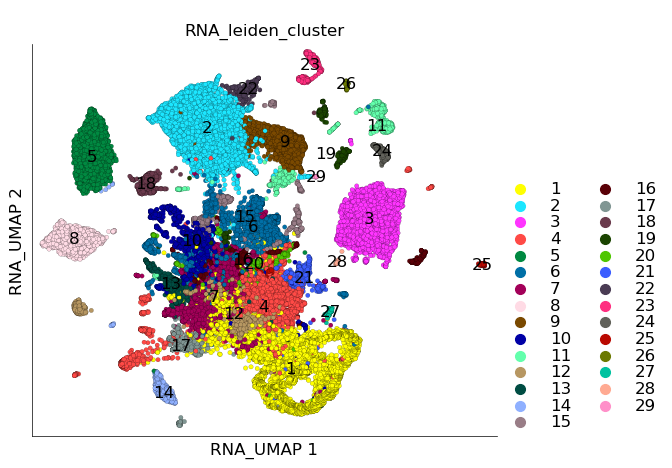

In [222]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
    savename='/Users/saatvikviniak/Desktop/Lab-work/Layden Lab/GPCR DeOrphanization/GPR149/sc-RNA-atlas/External Segment of globus pallidus/RNA_leiden_cluster.tiff', 
    save_dpi=300
)
# save dpi to save

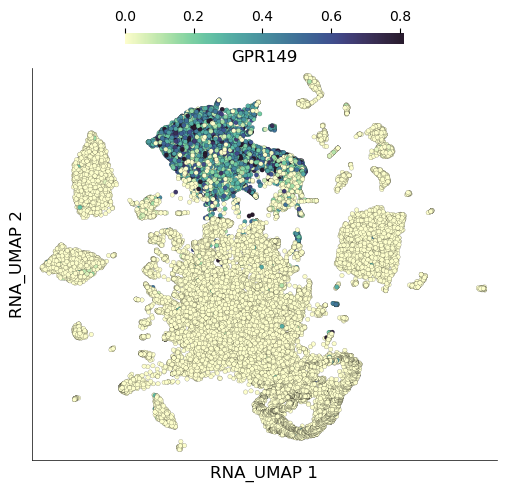

In [269]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by=['GPR149']
)



In [226]:
status = results[3]['GZMB'] # first set of brackets essentially just says what layer
print(status) 

off


In [251]:
updated_annotations = {-1: ['UNKNOWN'],
 1: ['OLIGO'],
 2: ['MSN-D2'], # going with MSN-D2 as it appears that FOXP1 dominates in terms of expression here, whereas as MSN-D1's also have high FOXP2 prescence
 3: ['MGL'],
 4: ['OLIGO'],
 5: ['ASTRO'],
 6: ['OLIGO'],
 7: ['OLIGO'],
 8: ['OPC'],
 9: ['MSN-ECC'], # Could be MSN-D1, heavy concentration of FOXP2 in this cluster, more likely MSN-ECC 
 10: ['OLIGO'],
 11: ['GABA1/2?'], # addresing this now. Not sure, appears to be a split population of both Oligodendrocytes and GABA1/2 neurons, not sure
 12: ['OLIGO'],
 13: ['OLIGO'],
 14: ['ASTRO'],
 15: ['OLIGO'],
 16: ['OLIGO'],
 17: ['OLIGO'],
 18: ['NT-GABA1'], # need to differeniate between gaba1 and gaba2 neurons. Choosing GABA1 as GAD1 has a deeper blue present inside this area
 19: ['OLIGO'],
 20: ['OLIGO'],
 21: ['OLIGO'],
 22: ['MSN-D2'], # higher concentration of FOXP1 than FOXP2, suggesting this is likely just a D2-MSN, as they also coexpressing GAD2 higher
 23: ['PIA'],
 24: ['MAC'],
 25: ['OLIGO'],
 26: ['CAP'], 
 27: ['OLIGO'],
 28: ['MGL'],
 29: ['NEUR']}

In [393]:
for cluster, gene_calls in results.items():
    if gene_calls.get('GPR149') == 'on':
        print(f"Cluster {cluster} expresses GPR149 — annotated as: {updated_annotations[cluster]}")

Cluster -1 expresses GPR149 — annotated as: ['UNKNOWN']
Cluster 2 expresses GPR149 — annotated as: ['MSN-D2']
Cluster 9 expresses GPR149 — annotated as: ['MSN-ECC']
Cluster 15 expresses GPR149 — annotated as: ['OLIGO']
Cluster 18 expresses GPR149 — annotated as: ['NT-GABA1']
Cluster 22 expresses GPR149 — annotated as: ['MSN-D2']


In [255]:
clean_annotations = {}

for key, value_list in updated_annotations.items():
    first_item = value_list[0]
    clean_annotations[key] = first_item

In [ ]:
cluster_ids = ds.cells.fetch_all('RNA_leiden_cluster')
cell_types = [clean_annotations.get(cluster, 'Unannotated') for cluster in cluster_ids]

In [256]:
ds.cells.insert('cell_type', cell_types, overwrite=True)

/opt/anaconda3/lib/python3.12/site-packages/scarf/plots.py:597: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


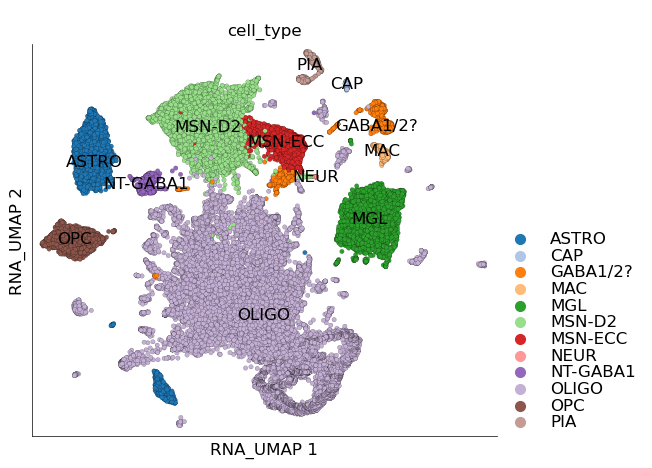

In [268]:
ds.plot_layout(
    layout_key='RNA_UMAP', 
    color_by='cell_type',
    legend_ondata=True, #puts text straight onto the cluster
    savename='/Users/saatvikviniak/Desktop/Lab-work/Layden Lab/GPCR DeOrphanization/GPR149/sc-RNA-atlas/External Segment of globus pallidus/Labeled_UMAP_projection.tiff', 
    save_dpi=600 
)

#### Now Making violin plots if ts has this feature

In [279]:
#find the exact naming scheme for GPR149
gene_names = ds.RNA.feats.fetch_all('names')
gene_idx = next(i for i, name in enumerate(gene_names) if name.upper() == 'GPR149')
actual_name = gene_names[gene_idx]

In [378]:
## Now gert the exact RAW counts from ds.RNA.rawData, and then normalize them again
raw_counts = ds.RNA.rawData[:, gene_idx].compute()
log_expr = np.log1p(raw_counts)
cell_types = ds.cells.fetch_all('cell_type')

In [379]:
cell_types

array(['OLIGO', 'OLIGO', 'MGL', ..., 'OLIGO', 'MSN-ECC', 'OLIGO'],
      dtype='<U8')

In [390]:
violin_df = pd.DataFrame({
    'Expression (log1p)': log_expr,
    'Cell Type': cell_types})

#define the list of cell types we want to exclude (where gpr149 IS NOT marked as on).
exclude_cells = ['UNKNOWN', 'MGL', 'OPC', 'MAC', 'CAP', 'NEUR', 'PIA', 'ASTRO', 'GABA1/2?']


violin_df = violin_df[~violin_df['Cell Type'].isin(exclude_cells)]

# Cluster 2 expresses GPR149 — annotated as: ['MSN-D2']
# Cluster 9 expresses GPR149 — annotated as: ['MSN-ECC']
# Cluster 15 expresses GPR149 — annotated as: ['OLIGO']
# Cluster 18 expresses GPR149 — annotated as: ['NT-GABA1']
# Cluster 22 expresses GPR149 — annotated as: ['MSN-D2']

In [391]:
violin_df.groupby('Cell Type')['Expression (log1p)'].describe()

,count,mean,std,min,25%,50%,75%,max
Cell Type,,,,,,,,
MSN-D2,8667.0,2.377417,0.731406,0.0,2.079442,2.484907,2.890372,4.276666
MSN-ECC,1756.0,2.047524,1.144461,0.0,1.386294,2.302585,2.944439,4.110874
NT-GABA1,478.0,0.244502,0.463070,0.0,0.000000,0.000000,0.693147,2.302585
OLIGO,24571.0,0.024780,0.227521,0.0,0.000000,0.000000,0.000000,3.784190


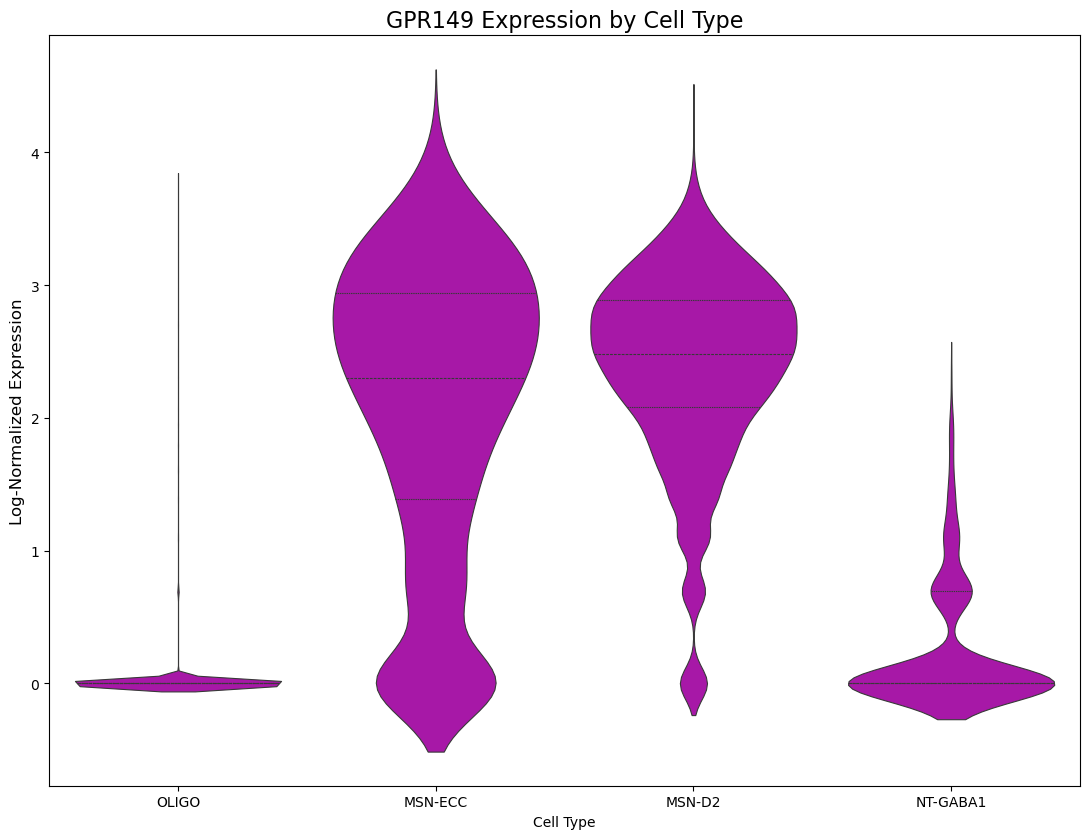

In [429]:
# now actually making the plot
plt.figure(figsize=(11, 8.5))

sns.violinplot(
    data=violin_df, 
    x='Cell Type',
    y='Expression (log1p)', 
    inner='quart',
    color='m',
    linewidth=0.8,
    #cut=0,
    density_norm='width', #makes all violins are the same visual width
)


plt.title(f'{actual_name} Expression by Cell Type', fontsize=16)
plt.ylabel('Log-Normalized Expression', fontsize=12)
plt.xlabel('Cell Type')
plt.tight_layout()

plt.savefig("GPR149_violin.tiff", dpi=300)

plt.show()


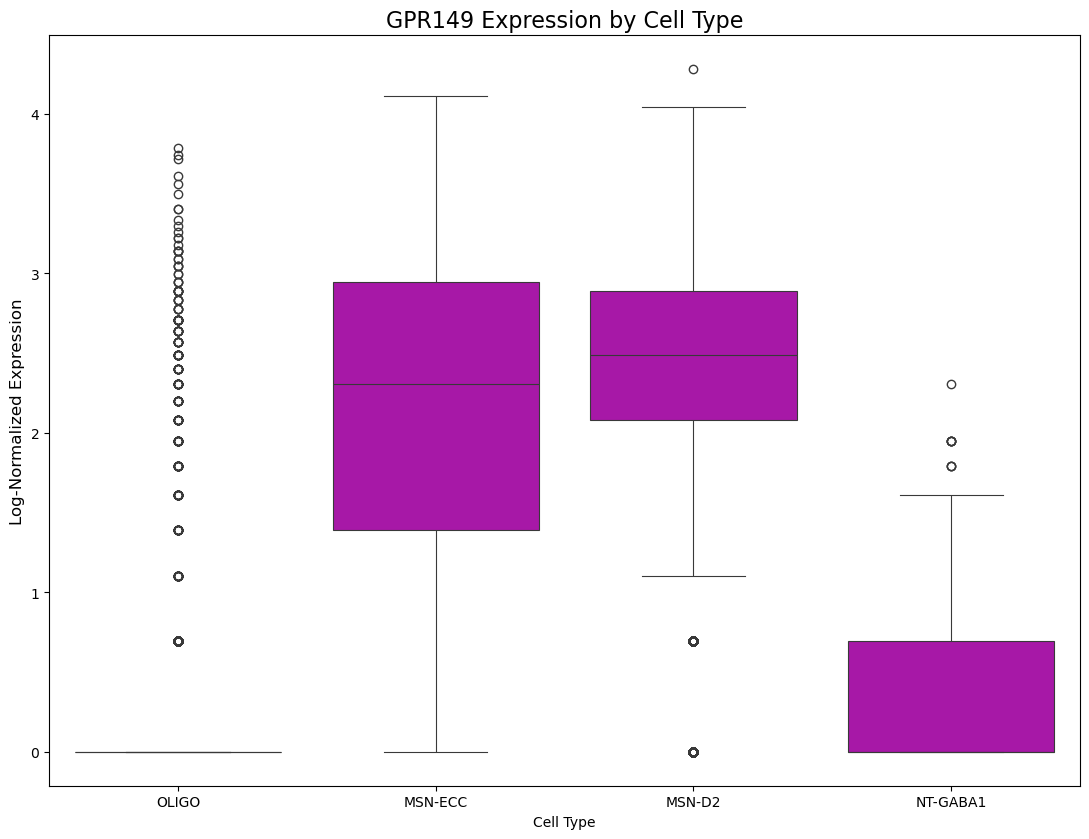

In [389]:
# now actually making the plot
plt.figure(figsize=(11, 8.5))

sns.boxplot(
    data=violin_df, 
    x='Cell Type',
    y='Expression (log1p)', 
    color='m',
    #showfliers=False,
    linewidth=0.8
    
)


plt.title(f'{actual_name} Expression by Cell Type', fontsize=16)
plt.ylabel('Log-Normalized Expression', fontsize=12)
plt.xlabel('Cell Type')
plt.tight_layout()
plt.show()

In [408]:
markers[markers['feature_name'] == 'GPR149']

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value
277,1,GPR149,46750.0,0.26274,0.36599,0.02092,0.96228,0.05258,17.49068,0.0


In [410]:
markers[markers['feature_name'] == 'CARTPT']

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value
8031,1,CARTPT,596.0,0.06822,0.0018,0.00063,0.02634,0.00482,2.8662,8.336017e-85


In [411]:
ds.RNA.feats.head()

,I,ids,names,I__hvgs,dropOuts,feature_is_filtered,nCells,stats_I_avg,stats_I_c_var__200__0.1,stats_I_normed_n,stats_I_normed_tot,stats_I_nz_mean,stats_I_sigmas
0,True,ENSG00000271098,IMMP1LP3,True,50783,False,47,0.000095,9.061598,37.0,4.845531,0.130960,0.000032
1,True,ENSG00000251026,NIHCOLE,True,50412,False,418,0.000770,8.657837,284.0,39.145037,0.137835,0.000349
2,True,ENSG00000129451,KLK10,False,50690,False,140,0.000184,7.751044,68.0,9.332586,0.137244,0.000060
3,True,ENSG00000163568,AIM2,False,49841,False,989,0.001649,6.840544,758.0,83.833196,0.110598,0.000665
4,True,ENSG00000253327,RAD21-AS1,False,50687,False,143,0.000215,6.175565,98.0,10.934750,0.111579,0.000062


TypeError: 'MetaData' object is not subscriptable